In [58]:
import requests
import json
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
from datetime import datetime

In [59]:
class QCamberAPI:
    """Helper class để tương tác với QCamber REST API"""
    
    def __init__(self, base_url="http://localhost:8686"):
        self.base_url = base_url
        self.session = requests.Session()
    
    def check_status(self):
        """Kiểm tra trạng thái server"""
        try:
            response = self.session.get(f"{self.base_url}/api/status", timeout=5)
            response.raise_for_status()
            return response.json()
        except requests.exceptions.RequestException as e:
            return {"error": str(e)}
    
    def capture_pcb(self, job_name, layer_name, x=0, y=0, zoom=1.0):
        """
        Yêu cầu chụp ảnh PCB (chỉ gửi request, không đợi ảnh)
        
        Parameters:
        -----------
        job_name : str
            Tên job PCB
        layer_name : str
            Tên layer (top, bottom, inner, etc.)
        x : float
            Tọa độ X (inch)
        y : float
            Tọa độ Y (inch)
        zoom : float
            Mức zoom (1.0 = 100%)
        
        Returns:
        --------
        dict : Response từ server
        """
        payload = {
            "jobName": job_name,
            "layerName": layer_name,
            "x": x,
            "y": y,
            "zoom": zoom
        }
        
        try:
            response = self.session.post(
                f"{self.base_url}/api/capture",
                json=payload,
                timeout=10
            )
            response.raise_for_status()
            return response.json()
        except requests.exceptions.RequestException as e:
            return {"error": str(e)}
    
    # ✅ THÊM METHOD MỚI
    def capture_pcb_with_image(self, job_name, layer_name, x=0, y=0, zoom=1.0, timeout=30):
        """
        Yêu cầu chụp ảnh PCB và nhận ảnh về
        
        Parameters:
        -----------
        job_name : str
            Tên job PCB
        layer_name : str
            Tên layer (top, bottom, inner, etc.)
        x : float
            Tọa độ X (inch)
        y : float
            Tọa độ Y (inch)
        zoom : float
            Mức zoom (1.0 = 100%)
        timeout : int
            Timeout in seconds
        
        Returns:
        --------
        tuple: (metadata: dict, image: PIL.Image hoặc None)
        """
        import uuid
        from PIL import Image
        from io import BytesIO
        import time
        
        # Generate unique request ID
        request_id = f"req_{uuid.uuid4().hex[:16]}"
        
        payload = {
            "requestId": request_id,
            "jobName": job_name,
            "layerName": layer_name,
            "x": x,
            "y": y,
            "zoom": zoom
        }
        
        try:
            # Bước 1: Gửi yêu cầu capture
            print(f"📤 Sending capture request with ID: {request_id}")
            response = self.session.post(
                f"{self.base_url}/api/capture",
                json=payload,
                timeout=timeout
            )
            
            # Kiểm tra response
            if response.status_code != 200:
                print(f"❌ Error: HTTP {response.status_code}")
                return {"error": f"HTTP {response.status_code}"}, None
            
            # Kiểm tra content type
            content_type = response.headers.get('Content-Type', '')
            print(f"📥 Response Content-Type: {content_type}")
            
            # Nếu nhận được JSON (acknowledgment)
            if 'application/json' in content_type:
                ack = response.json()
                print(f"✅ Acknowledgment: {ack}")
                
                # Đợi một chút để QCamber xử lý
                print(f"⏳ Waiting for QCamber to process...")
                time.sleep(1)
                
                # Gửi request thứ 2 với cùng connection
                # (Trong implementation hiện tại, ảnh sẽ được gửi trong cùng response)
                return ack, None
            
            # Nếu nhận được ảnh PNG
            elif 'image/png' in content_type:
                print(f"✅ Image received: {len(response.content)} bytes")
                image = Image.open(BytesIO(response.content))
                
                metadata = {
                    "requestId": request_id,
                    "jobName": job_name,
                    "layerName": layer_name,
                    "x": x,
                    "y": y,
                    "zoom": zoom,
                    "imageSize": len(response.content)
                }
                
                return metadata, image
            
            else:
                print(f"❌ Unexpected content type: {content_type}")
                return {"error": f"Unexpected content type: {content_type}"}, None
                
        except requests.exceptions.Timeout:
            print(f"❌ Timeout after {timeout} seconds")
            return {"error": "Timeout"}, None
        except requests.exceptions.RequestException as e:
            print(f"❌ Request error: {e}")
            return {"error": str(e)}, None
        except Exception as e:
            print(f"❌ Unexpected error: {e}")
            return {"error": str(e)}, None
    
    def is_server_running(self):
        """Kiểm tra xem server có đang chạy không"""
        try:
            response = self.session.get(f"{self.base_url}/api/status", timeout=2)
            return response.status_code == 200
        except:
            return False

# ✅ Khởi tạo lại API client với class mới
api = QCamberAPI()

print("✅ QCamberAPI class updated with capture_pcb_with_image() method")

✅ QCamberAPI class updated with capture_pcb_with_image() method


In [60]:
# Test 1: Kiểm tra server có đang chạy không
print("🔍 Checking if QCamber server is running...")
if api.is_server_running():
    print("✅ Server is running!")
else:
    print("❌ Server is NOT running. Please start QCamber application first.")

🔍 Checking if QCamber server is running...
✅ Server is running!


In [61]:
# Test 2: Lấy thông tin status
print("\n📊 Getting server status...")
status = api.check_status()
print(json.dumps(status, indent=2))


📊 Getting server status...
{
  "port": 8686,
  "status": "ok"
}


In [62]:
# Troubleshooting helper
def diagnose_connection():
    """Chẩn đoán vấn đề kết nối"""
    print("🔍 Diagnosing connection issues...\n")
    
    # Check 1: Port listening
    import socket
    print("1. Checking if port 8686 is open...")
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    result = sock.connect_ex(('localhost', 8686))
    if result == 0:
        print("   ✅ Port 8686 is open")
    else:
        print("   ❌ Port 8686 is closed")
        print("   → Solution: Start QCamber application")
    sock.close()
    
    # Check 2: HTTP response
    print("\n2. Checking HTTP response...")
    try:
        response = requests.get("http://localhost:8686/api/status", timeout=2)
        print(f"   ✅ HTTP {response.status_code}")
    except requests.exceptions.ConnectionError:
        print("   ❌ Connection refused")
        print("   → Solution: Verify QCamber is running")
    except requests.exceptions.Timeout:
        print("   ❌ Connection timeout")
        print("   → Solution: Check firewall settings")
    
    # Check 3: JSON parsing
    print("\n3. Checking JSON response...")
    try:
        status = api.check_status()
        if 'error' in status:
            print(f"   ❌ Error: {status['error']}")
        else:
            print(f"   ✅ JSON parsed successfully")
    except Exception as e:
        print(f"   ❌ Exception: {e}")

# Chạy diagnostics khi gặp vấn đề
diagnose_connection()

🔍 Diagnosing connection issues...

1. Checking if port 8686 is open...
   ✅ Port 8686 is open

2. Checking HTTP response...
   ✅ HTTP 200

3. Checking JSON response...
   ✅ JSON parsed successfully


📤 Sending capture request with ID: req_a71b2e399a464852
📥 Response Content-Type: image/png
✅ Image received: 24892 bytes
✅ Success! Image: (2322, 1752)
📁 Also saved to: None
📥 Response Content-Type: image/png
✅ Image received: 24892 bytes
✅ Success! Image: (2322, 1752)
📁 Also saved to: None


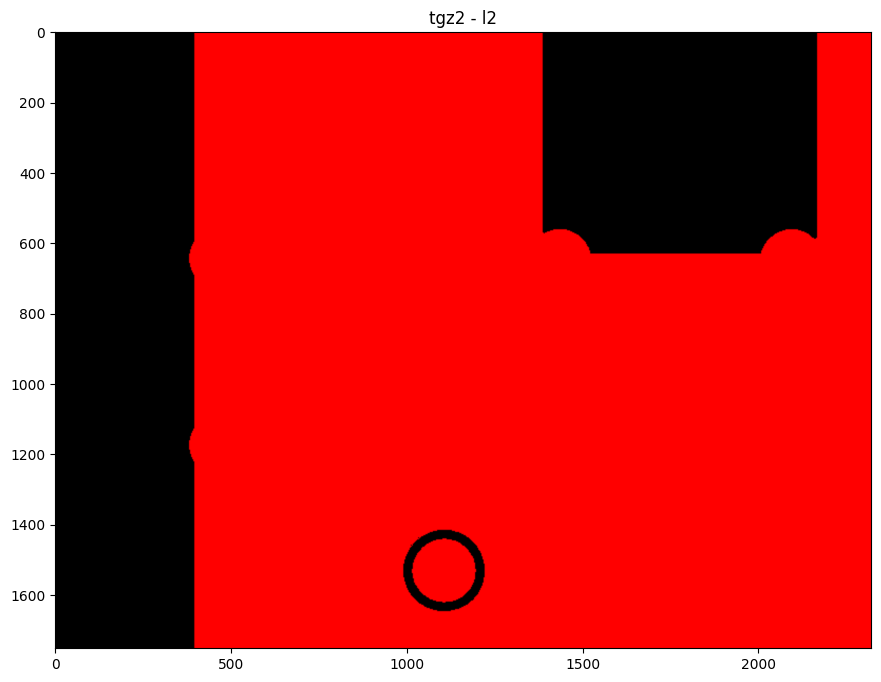

In [64]:
# Test với layer cụ thể
metadata, image = api.capture_pcb_with_image(
    job_name="tgz2",  # Phải match với job đang mở
    layer_name="l2",
    x=1.5,
    y=2.0,
    zoom=128.0
)

if image:
    print(f"✅ Success! Image: {image.size}")
    print(f"📁 Also saved to: {metadata.get('savedPath')}")
    
    # Display image
    plt.figure(figsize=(12, 8))
    plt.imshow(image)
    plt.title(f"{metadata.get('jobName')} - {metadata.get('layerName')}")
    plt.show()
else:
    print(f"❌ Error: {metadata.get('error')}")

TEST: Parse coordinates in database format (x;y)

📦 Database coordinate format: '1.518795;2.0109942'
✅ Parsed: {'x': 1.518795, 'y': 2.0109942}

📤 Sending to QCamber with parsed coordinates...
📤 Sending capture request with ID: req_cff46daffc304d90
📥 Response Content-Type: image/png
✅ Image received: 24712 bytes
✅ Success! Image size: (2322, 1752)
✅ Metadata: {
  "requestId": "req_cff46daffc304d90",
  "jobName": "tgz2",
  "layerName": "l2",
  "x": 1.518795,
  "y": 2.0109942,
  "zoom": 128.0,
  "imageSize": 24712
}
📥 Response Content-Type: image/png
✅ Image received: 24712 bytes
✅ Success! Image size: (2322, 1752)
✅ Metadata: {
  "requestId": "req_cff46daffc304d90",
  "jobName": "tgz2",
  "layerName": "l2",
  "x": 1.518795,
  "y": 2.0109942,
  "zoom": 128.0,
  "imageSize": 24712
}


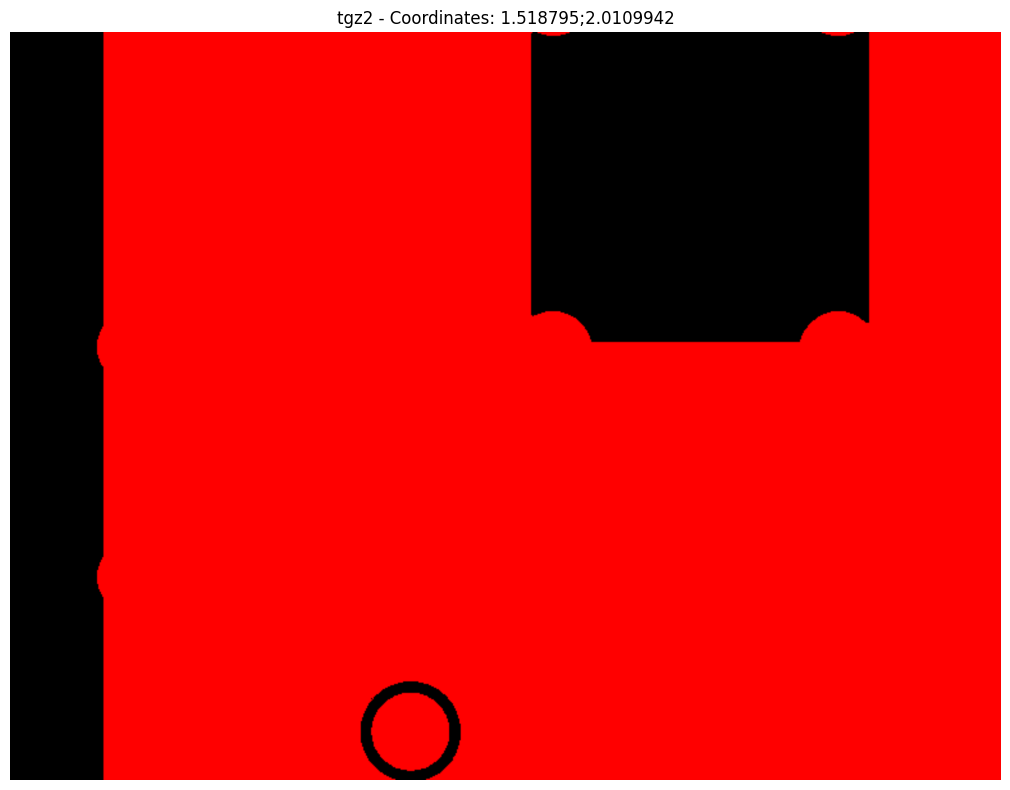

In [67]:
# Test parse coordinates format - Database format "x;y"
print("=" * 60)
print("TEST: Parse coordinates in database format (x;y)")
print("=" * 60)

# Simulating database format
db_coord_str = "1.518795;2.0109942"
print(f"\n📦 Database coordinate format: '{db_coord_str}'")

# Parse using semicolon separator
def parse_coord_semicolon(coord_str):
    """Parse coordinates từ database format 'x;y'"""
    try:
        parts = coord_str.split(';')
        if len(parts) >= 2:
            x = float(parts[0].strip())
            y = float(parts[1].strip())
            return {"x": x, "y": y}
    except Exception as e:
        print(f"❌ Error: {e}")
    return None

coords = parse_coord_semicolon(db_coord_str)
print(f"✅ Parsed: {coords}")

# Now use with QCamber API
print("\n📤 Sending to QCamber with parsed coordinates...")
metadata, image = api.capture_pcb_with_image(
    job_name="tgz2",
    layer_name="l2",
    x=coords['x'],
    y=coords['y'],
    zoom=128.0
)

if image:
    print(f"✅ Success! Image size: {image.size}")
    print(f"✅ Metadata: {json.dumps(metadata, indent=2)}")
    
    # Display image
    plt.figure(figsize=(12, 8))
    plt.imshow(image)
    plt.title(f"{metadata.get('jobName')} - Coordinates: {db_coord_str}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f"❌ Error: {metadata.get('error')}")

In [66]:
# Test: Support both coordinate formats
print("\n" + "=" * 60)
print("TEST: Support both coordinate formats")
print("=" * 60)

def parse_coordinates(coord_input):
    """
    Parse coordinates từ hai format:
    1. JSON: '{"x": 1.5, "y": 2.0}'
    2. Semicolon: '1.518795;2.0109942'
    """
    if isinstance(coord_input, str):
        # Format 1: JSON
        if coord_input.startswith('{'):
            try:
                import json
                parsed = json.loads(coord_input)
                if 'x' in parsed and 'y' in parsed:
                    return {"x": float(parsed['x']), "y": float(parsed['y'])}
            except:
                pass
        
        # Format 2: Semicolon
        if ';' in coord_input:
            parts = coord_input.split(';')
            if len(parts) >= 2:
                try:
                    x = float(parts[0].strip())
                    y = float(parts[1].strip())
                    return {"x": x, "y": y}
                except:
                    pass
    
    return None

# Test cases
test_cases = [
    ('{"x": 1.5, "y": 2.0}', "JSON format"),
    ('1.518795;2.0109942', "Semicolon format (database)"),
    ('150;250', "Semicolon format (integers)"),
]

print("\n🧪 Testing coordinate parsing:\n")
for coord_str, desc in test_cases:
    result = parse_coordinates(coord_str)
    status = "✅" if result else "❌"
    print(f"{status} {desc}")
    print(f"   Input:  '{coord_str}'")
    print(f"   Output: {result}\n")


TEST: Support both coordinate formats

🧪 Testing coordinate parsing:

✅ JSON format
   Input:  '{"x": 1.5, "y": 2.0}'
   Output: {'x': 1.5, 'y': 2.0}

✅ Semicolon format (database)
   Input:  '1.518795;2.0109942'
   Output: {'x': 1.518795, 'y': 2.0109942}

✅ Semicolon format (integers)
   Input:  '150;250'
   Output: {'x': 150.0, 'y': 250.0}

